In [144]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft
from skimage import metrics
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import rotate, resize
from skimage.transform import radon, iradon
from scipy import ndimage
from scipy.ndimage import zoom
from skimage.metrics import structural_similarity as ssim

In [74]:
# ----------------------------
# 1. Radon Transform
# ----------------------------
def radon_transform(image, steps):
    sinogram = radon(image, theta=np.linspace(0, 180, steps, endpoint=False), circle=True)
    return sinogram

In [75]:
# ----------------------------
# 2. Pad Sinogram to Square
# ----------------------------
def sinogram_circle_to_square(sinogram):
    diagonal = int(np.ceil(np.sqrt(2) * sinogram.shape[0]))
    pad = diagonal - sinogram.shape[0]
    old_center = sinogram.shape[0] // 2
    new_center = diagonal // 2
    pad_before = new_center - old_center
    pad_width = ((pad_before, pad - pad_before), (0, 0))
    return np.pad(sinogram, pad_width, mode='constant', constant_values=0)

In [149]:
# ----------------------------
# 3. Filtered Backprojection
# ----------------------------
def iradon_transform(radon_image, theta, interpolation='linear'):
    output_size = radon_image.shape[0]
    radon_image = sinogram_circle_to_square(radon_image)
    th = np.deg2rad(theta)  # convert to radians

    # pad to next power of 2 for FFT
    proj_size_padded = max(64, int(2 ** np.ceil(np.log2(2 * radon_image.shape[0]))))
    pad_width = ((0, proj_size_padded - radon_image.shape[0]), (0, 0))
    img = np.pad(radon_image, pad_width, mode='constant', constant_values=0)

    # Fourier filtering (ramp filter)
    freqs = np.fft.fftfreq(proj_size_padded).reshape(-1, 1)
    ramp_filter = 2 * np.abs(freqs)
    projection_fft = np.fft.fft(img, axis=0) * ramp_filter
    radon_filtered = np.real(np.fft.ifft(projection_fft, axis=0))
    radon_filtered = radon_filtered[:radon_image.shape[0], :]

    # Backprojection
    reconstructed = np.zeros((output_size, output_size), dtype=np.float64)
    X, Y = np.mgrid[0:output_size, 0:output_size]
    xpr = X - output_size // 2
    ypr = Y - output_size // 2
    mid_index = radon_image.shape[0] // 2

    for i in range(len(theta)):
        t = ypr * np.cos(th[i]) - xpr * np.sin(th[i])
        x = np.arange(radon_filtered.shape[0]) - mid_index

        if interpolation == 'linear':
            backproj = np.interp(t, x, radon_filtered[:, i], left=0, right=0)
        else:
            from scipy.interpolate import interp1d
            interpolant = interp1d(x, radon_filtered[:, i], kind=interpolation,
                                   bounds_error=False, fill_value=0)
            backproj = interpolant(t)
        reconstructed += backproj

    # Mask outside circle
    radius = output_size // 2
    mask = (xpr**2 + ypr**2) <= radius**2
    reconstructed[~mask] = 0

    # Normalize
    return reconstructed * np.pi / (2 * len(th))


In [150]:
def subsample_sinogram(sino, factor):
    #subsample the sinogram by a specified factor
    #sinogram_final = np.zeros_like(sino)
    #sinogram_final[: : factor, :] = sino[: : factor, :]
    return sino[: : factor, :]

In [151]:
def Mean_Sq_Er(recon, ground_truth):
    # If recon is larger than 220x220 due to the padding, crop to center
    if recon.shape != ground_truth.shape:
        recon = resize(recon, ground_truth.shape, order=1, preserve_range=True)
#    if recon.shape != ground_truth.shape:
#        rows, cols = recon.shape         # Calculate cropping bounds
#        target_rows, target_cols = ground_truth.shape

        #Identify the boundary coordinates
#        row_start = (rows - target_rows) // 2
#        row_end = row_start + target_rows
#        col_start = (cols - target_cols) // 2
#        col_end = col_start + target_cols

        #Crop out the stuff outside the boundary to get only the stuff that is not padded
#        recon = recon[row_start:row_end, col_start:col_end]

    MSE = np.mean((recon - ground_truth) ** 2)
    return MSE

def Root_Mean_Sq_Er(MSE):
    RMSE = np.sqrt(MSE)
    return RMSE

def Peak_Sig_Noise_R(MSE, max_value = 1):      #max_value is 1 because the signal is normalised
    PSNR = 20*np.log10(max_value / np.sqrt(MSE))
    return PSNR

def Calculate_SSIM(recon, ground_truth):
#    if recon.shape != ground_truth.shape:
#        rows, cols = recon.shape         # Calculate cropping bounds
#        target_rows, target_cols = ground_truth.shape

        #Identify the boundary coordinates (similar to the mean square function)
#        row_start = (rows - target_rows) // 2
#        row_end = row_start + target_rows
#        col_start = (cols - target_cols) // 2
#        col_end = col_start + target_cols

        #Crop out the stuff outside the boundary
#        recon = recon[row_start:row_end, col_start:col_end]
    if recon.shape != ground_truth.shape:
        recon = resize(recon, ground_truth.shape, order=1, preserve_range=True)
         
    SSIM_score = ssim(recon, ground_truth, data_range = image.max()-image.min())
    return SSIM_score

In [152]:
# ----------------------------
# 4. Main
# ----------------------------
# Load image
imagename = 'C:/Users/Browne/Desktop/BMED3501 Matlab/BMED3501 Lab Report/transverseslice.jpg'  # replace with your image path
image = imread(imagename)
if image.ndim == 3:
    image = rgb2gray(image)
image = resize(image, (220, 220), anti_aliasing=True)

# Radon Transform
steps = 220
sinogram = radon_transform(image, steps)

#Subsampled sinograms to show fewer detectors
sinogram_2 = subsample_sinogram(sinogram, 2)
sinogram_3 = subsample_sinogram(sinogram, 3)
sinogram_5 = subsample_sinogram(sinogram, 5)
sinogram_7 = subsample_sinogram(sinogram, 7)
sinogram_16 = subsample_sinogram(sinogram, 16)

# Theta angles
theta = np.linspace(0., 180., steps, endpoint=False)
# FBP reconstruction
reconstruction_fbp_original = iradon_transform(sinogram, theta)
reconstruction_fbp_2 = iradon_transform(sinogram_2, theta)
reconstruction_fbp_3 = iradon_transform(sinogram_3, theta)
reconstruction_fbp_5 = iradon_transform(sinogram_5, theta)
reconstruction_fbp_7 = iradon_transform(sinogram_7, theta)
reconstruction_fbp_16 = iradon_transform(sinogram_16, theta)

C:\Users\Browne\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\skimage\transform\radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


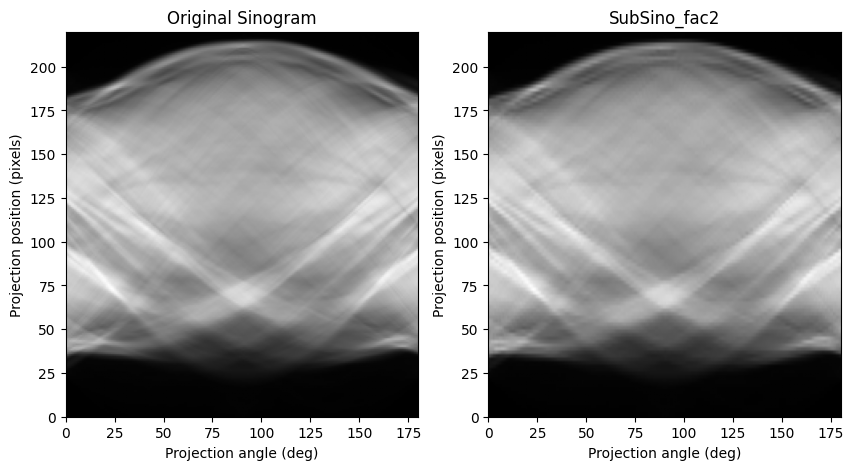

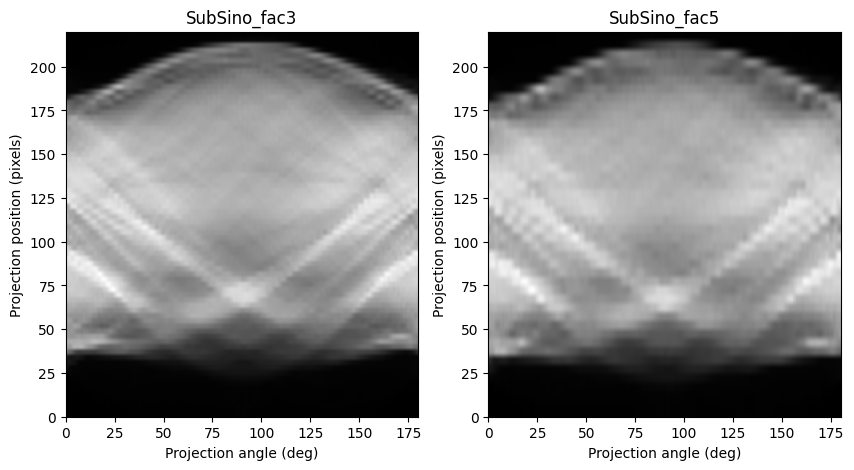

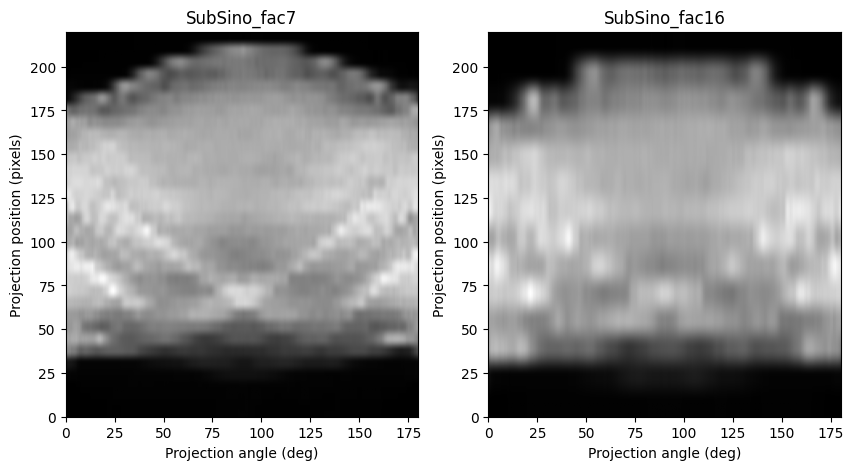

In [153]:
# ----------------------------
# 5. Plot results of sinograms
# ----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.set_title("Original Sinogram")
ax1.imshow(sinogram, cmap='gray', aspect='auto',
           extent=(0, 180, 0, sinogram.shape[0]))
ax1.set_xlabel("Projection angle (deg)")
ax1.set_ylabel("Projection position (pixels)")

ax2.set_title("SubSino_fac2")
ax2.imshow(sinogram_2, cmap='gray', aspect='auto',
           extent=(0, 180, 0, sinogram.shape[0]))
ax2.set_xlabel("Projection angle (deg)")
ax2.set_ylabel("Projection position (pixels)")

plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.set_title("SubSino_fac3")
ax1.imshow(sinogram_3, cmap='gray', aspect='auto',
           extent=(0, 180, 0, sinogram.shape[0]))
ax1.set_xlabel("Projection angle (deg)")
ax1.set_ylabel("Projection position (pixels)")

ax2.set_title("SubSino_fac5")
ax2.imshow(sinogram_5, cmap='gray', aspect='auto',
           extent=(0, 180, 0, sinogram.shape[0]))
ax2.set_xlabel("Projection angle (deg)")
ax2.set_ylabel("Projection position (pixels)")

plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.set_title("SubSino_fac7")
ax1.imshow(sinogram_7, cmap='gray', aspect='auto',
           extent=(0, 180, 0, sinogram.shape[0]))
ax1.set_xlabel("Projection angle (deg)")
ax1.set_ylabel("Projection position (pixels)")

ax2.set_title("SubSino_fac16")
ax2.imshow(sinogram_16, cmap='gray', aspect='auto',
           extent=(0, 180, 0, sinogram.shape[0]))
ax2.set_xlabel("Projection angle (deg)")
ax2.set_ylabel("Projection position (pixels)")

plt.show()

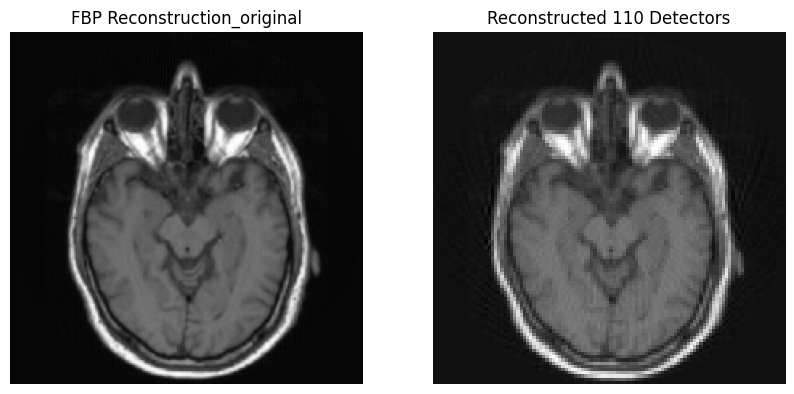

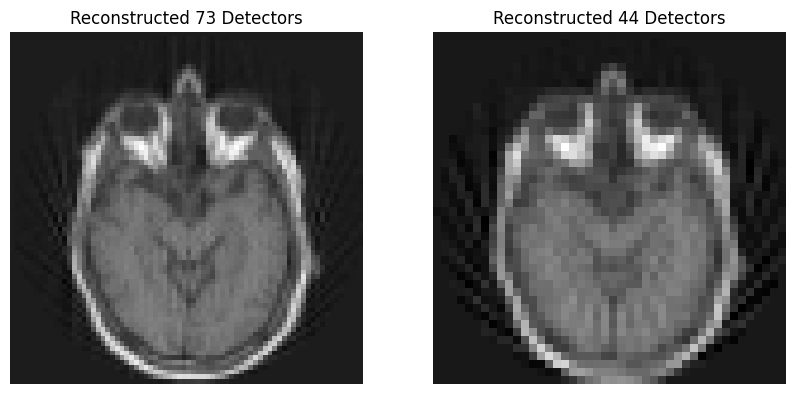

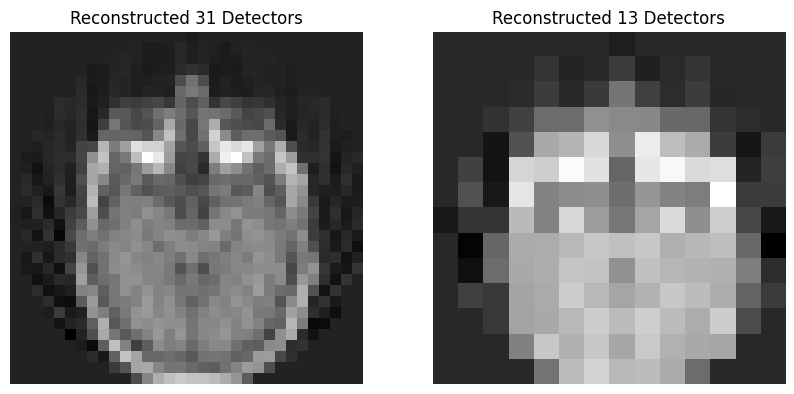

In [154]:
# ----------------------------
# 5. Plot results of recon. images
# ----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.set_title("FBP Reconstruction_original")
ax1.imshow(reconstruction_fbp_original, cmap='gray')
ax1.axis('off')

ax2.set_title("Reconstructed 110 Detectors")
ax2.imshow(reconstruction_fbp_2, cmap='gray')
ax2.axis('off')

plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.set_title("Reconstructed 73 Detectors")
ax1.imshow(reconstruction_fbp_3, cmap='gray')
ax1.axis('off')

ax2.set_title("Reconstructed 44 Detectors")
ax2.imshow(reconstruction_fbp_5, cmap='gray')
ax2.axis('off')

plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.set_title("Reconstructed 31 Detectors")
ax1.imshow(reconstruction_fbp_7, cmap='gray')
ax1.axis('off')

ax2.set_title("Reconstructed 13 Detectors")
ax2.imshow(reconstruction_fbp_16, cmap='gray')
ax2.axis('off')

plt.show()

In [142]:
#------------------
# Quali. Metrics
#------------------

#MSE
MSE2 = Mean_Sq_Er(reconstruction_fbp_2, reconstruction_fbp_original)
MSE3 = Mean_Sq_Er(reconstruction_fbp_3, reconstruction_fbp_original)
MSE5 = Mean_Sq_Er(reconstruction_fbp_5, reconstruction_fbp_original)
MSE7 = Mean_Sq_Er(reconstruction_fbp_7, reconstruction_fbp_original)
MSE16 = Mean_Sq_Er(reconstruction_fbp_16, reconstruction_fbp_original)
print(MSE2, MSE3, MSE5, MSE7, MSE16)

#RMSE
RMSE2 = Root_Mean_Sq_Er(MSE2)
RMSE3 = Root_Mean_Sq_Er(MSE3)
RMSE5 = Root_Mean_Sq_Er(MSE5)
RMSE7 = Root_Mean_Sq_Er(MSE7)
RMSE16 = Root_Mean_Sq_Er(MSE16)
print(RMSE2, RMSE3, RMSE5, RMSE7, RMSE16)

#PSNR
PSNR2 = Peak_Sig_Noise_R(MSE2)
PSNR3 = Peak_Sig_Noise_R(MSE3)
PSNR5 = Peak_Sig_Noise_R(MSE5)
PSNR7 = Peak_Sig_Noise_R(MSE7)
PSNR16 = Peak_Sig_Noise_R(MSE16)
print(PSNR2, PSNR3, PSNR5, PSNR7, PSNR16)

#SSIM
SSIM2 = Calculate_SSIM(reconstruction_fbp_2, reconstruction_fbp_original)
SSIM3 = Calculate_SSIM(reconstruction_fbp_3, reconstruction_fbp_original)
SSIM5 = Calculate_SSIM(reconstruction_fbp_5, reconstruction_fbp_original)
SSIM7 = Calculate_SSIM(reconstruction_fbp_7, reconstruction_fbp_original)
SSIM16 = Calculate_SSIM(reconstruction_fbp_16, reconstruction_fbp_original)
print(SSIM2, SSIM3, SSIM5, SSIM7, SSIM16)


0.06755989377480401 0.2560613889998483 0.947079636682174 2.0432645662903446 11.449701257657875
0.25992286120078784 0.5060250873226033 0.973180166609541 1.4294280556538494 3.383740719626413
11.70311041946688 5.916559030172839 0.23613501126098246 -3.103246036568942 -10.587941553358826
0.7410347409828375 0.40632408787238655 0.24281326079487003 0.19234770500263845 0.12630726517260213
